In [2]:
import os
!pip install numpy
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
from torch.utils.data import DataLoader 
from PIL import Image
from matplotlib import pyplot as plt
import seaborn as sns
import wandb
import math
import argparse
import datetime
import math
from time import time

  Using cached numpy-2.4.1-cp312-cp312-macosx_14_0_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.1-cp312-cp312-macosx_14_0_x86_64.whl (6.5 MB)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ishittaiyer/Desktop/Research/multiscale diffusion/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ishittaiyer/Desktop/Research/multiscale diffusion/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/ishittaiyer/Desktop/Research/multiscale diffusion/.ve

In [3]:
from diffusion_score_models import DiffusionModel, VP, VE, GMM_score
device = "cpu"


In [4]:
diffusion_model = VP()

In [5]:
obj = torch.load("results/data/multiband_dataset_unbiased_and_biased.pt")
print(obj.keys())
for k in ["unbiased", "biased"]:
    v = obj[k]
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

dict_keys(['config', 'unbiased', 'biased'])
unbiased <class 'dict'> None None
biased <class 'dict'> None None


In [6]:
for split in ["unbiased", "biased"]:
    d = obj[split]
    print("\n===", split, "===")
    print("type:", type(d))
    print("keys:", list(d.keys()))

    # print shapes for any tensor values
    for k, v in d.items():
        if torch.is_tensor(v):
            print(f"  {k}: tensor {tuple(v.shape)} {v.dtype}")


=== unbiased ===
type: <class 'dict'>
keys: ['combined', 'coarse', 'fine', 'normalization']
  combined: tensor (10000, 128, 128) torch.float32
  coarse: tensor (10000, 128, 128) torch.float32
  fine: tensor (10000, 128, 128) torch.float32

=== biased ===
type: <class 'dict'>
keys: ['combined', 'coarse', 'fine', 'normalization', 'combined_biased', 'bias_meta']
  combined: tensor (10000, 128, 128) torch.float32
  coarse: tensor (10000, 128, 128) torch.float32
  fine: tensor (10000, 128, 128) torch.float32
  combined_biased: tensor (10000, 128, 128) torch.float32


In [7]:
# pick one:
x_unbiased = obj["unbiased"]["combined"]            # [N,H,W]
x_biased   = obj["biased"]["combined_biased"]       # [N,H,W]

# choose what to train on (biased)
x = x_biased

In [8]:
diffusion_model.beta_min = 1e-4
diffusion_model.beta_max = 2e-2


In [9]:
train_data = x.reshape(x.shape[0], -1)  # shape: (10000, 16384)
train_data.shape

torch.Size([10000, 16384])

In [10]:
score_model = GMM_score(train_data, 
                         marginal_prob_mean=diffusion_model.marginal_prob_mean, 
                         marginal_prob_std=diffusion_model.marginal_prob_std)

In [11]:
n_samples = 16
latents = torch.randn(n_samples, train_data.shape[1], device=device)  # initial noise in R^16384
samples = diffusion_model.SDEsampler(score_model, latents, num_steps=100)
samples = samples.reshape(n_samples, 1, 128, 128)

In [12]:
samples = samples.view(n_samples, 1, 128, 128)
samples

tensor([[[[ 0.6199,  0.7082,  0.5971,  ...,  0.3591,  0.3162,  0.4341],
          [ 0.4423,  0.6342,  0.5697,  ...,  0.2870,  0.0705,  0.1913],
          [ 0.2895,  0.4689,  0.4695,  ...,  0.3480,  0.0361,  0.0332],
          ...,
          [ 0.3509,  0.5465,  0.7621,  ...,  0.3760,  0.3515,  0.2765],
          [ 0.3557,  0.5503,  0.6553,  ...,  0.4131,  0.3413,  0.3082],
          [ 0.5369,  0.6365,  0.6009,  ...,  0.4196,  0.3917,  0.4750]]],


        [[[ 0.5812,  0.7298,  0.5626,  ...,  0.3797,  0.2861,  0.3935],
          [ 0.4950,  0.6298,  0.5782,  ...,  0.3025,  0.0440,  0.1588],
          [ 0.3007,  0.4858,  0.4929,  ...,  0.3850,  0.0160,  0.0521],
          ...,
          [ 0.3630,  0.5744,  0.7313,  ...,  0.3762,  0.3449,  0.2785],
          [ 0.3521,  0.5394,  0.6726,  ...,  0.4343,  0.3126,  0.2771],
          [ 0.5262,  0.6263,  0.5607,  ...,  0.4369,  0.3964,  0.4670]]],


        [[[ 0.6527,  0.6951,  0.6256,  ...,  0.3453,  0.2927,  0.4286],
          [ 0.4580,  0.656

In [13]:
import matplotlib.pyplot as plt

def show_samples_grid(samples, nrow=4):
    samples = samples.detach().cpu()

    # Optional: normalize if needed
    if samples.min() < 0 or samples.max() > 1:
        samples = (samples - samples.min()) / (samples.max() - samples.min())

    grid = samples[:nrow**2].reshape(nrow**2, 128, 128)
    fig, axs = plt.subplots(nrow, nrow, figsize=(8, 8))

    for i in range(nrow):
        for j in range(nrow):
            axs[i, j].imshow(grid[i * nrow + j].numpy(), cmap='gray')
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()




RuntimeError: Numpy is not available

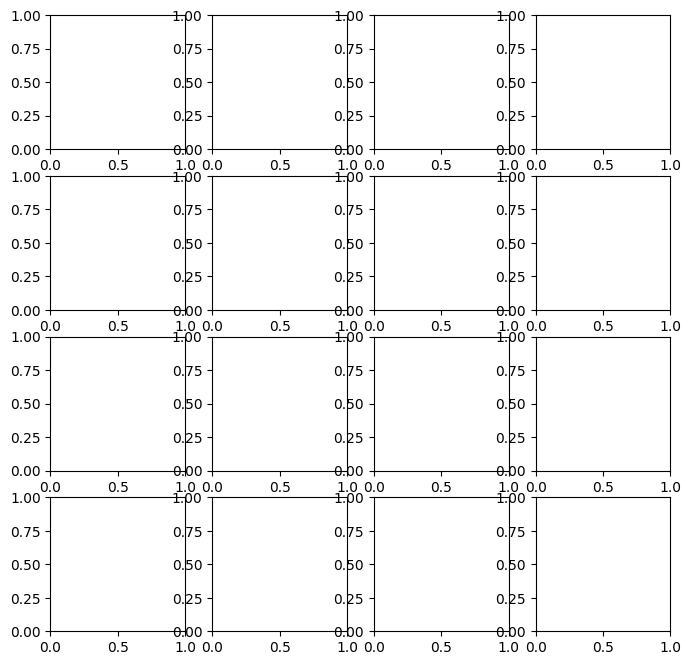

In [14]:
show_samples_grid(samples, nrow=4)


In [38]:
pip uninstall numpy -y && pip install numpy --no-binary :all:


Found existing installation: numpy 2.4.1
Uninstalling numpy-2.4.1:
  Successfully uninstalled numpy-2.4.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.7/20.7 MB 36.5 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... error
  error: subprocess-exited-with-error
  
  × installing build dependencies for numpy did not run successfully.
  │ exit code: 1
  ╰─> [148 lines of output]
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Installing backend dependencies: started
        Installing backend dependencies: finished with status 'error'
        error: subprocess-exited-with-error
      
        × installing backend dependencies for meson-python did not run successfully.
        │ exit code: 1
        ╰─> [130 lines of output]
              Installing build dependencies: started
 